In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

file_path = '/content/tugas_pert5.jpeg'

# Membaca gambar menggunakan PIL dan mengubahnya menjadi array NumPy
image_pil = Image.open(file_path)
image_np = np.array(image_pil)

print(f"Gambar berhasil dimuat dari: {file_path}")
print(f"Ukuran gambar awal: {image_np.shape}")

Gambar berhasil dimuat dari: /content/tugas_pert5.jpeg
Ukuran gambar awal: (1156, 867, 3)


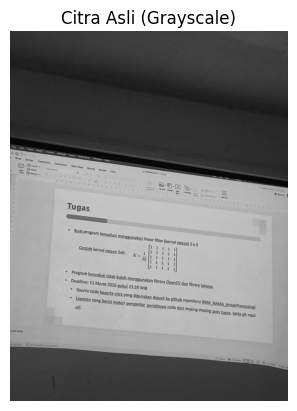

In [2]:
def rgb_to_grayscale(img_array):
    if len(img_array.shape) == 3:
        grayscale = np.dot(img_array[...,:3], [0.2989, 0.5870, 0.1140])
        return grayscale
    return img_array # Jika sudah grayscale, kembalikan apa adanya

# Mengubah citra menjadi grayscale
citra_gray = rgb_to_grayscale(image_np)

# Menampilkan citra grayscale
plt.imshow(citra_gray, cmap='gray')
plt.title("Citra Asli (Grayscale)")
plt.axis('off')
plt.show()

In [7]:
def konvolusi_5x5(citra_image):
    """
    Mengkonvolusi citra yang berukuran M x N dengan mask 5x5.
    Hasil konvolusi disimpan dalam matriks image_result.
    """
    M, N = citra_image.shape

    # Membuat matriks kosong untuk hasil
    image_result = np.zeros((M, N))

    # Definisi kernel rataan 5x5 (nilai 1/25 untuk setiap elemen)
    mask = np.ones((5, 5)) * (1.0 / 25.0)

    # Batas perulangan disesuaikan untuk kernel 5x5 (radius 2 piksel)
    # i dan j dimulai dari 2 hingga M-3 dan N-3
    for i in range(2, M - 2):
        for j in range(2, N - 2):
            total_pixel = 0.0

            # Perkalian elemen matriks citra dengan mask (kernel) 5x5
            for ki in range(-2, 3):
                for kj in range(-2, 3):
                    total_pixel += citra_image[i + ki][j + kj] * mask[ki + 2][kj + 2]

            image_result[i][j] = total_pixel

    return image_result

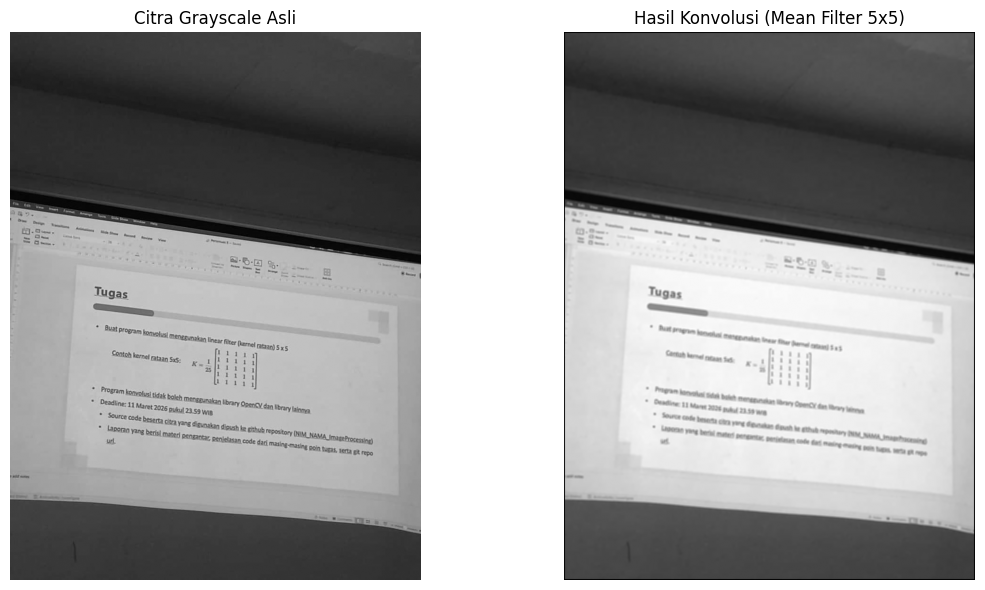

In [8]:
# Menjalankan fungsi konvolusi manual
citra_hasil = konvolusi_5x5(citra_gray)

# Menampilkan perbandingan sebelum dan sesudah konvolusi
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(citra_gray, cmap='gray')
ax[0].set_title('Citra Grayscale Asli')
ax[0].axis('off')

ax[1].imshow(citra_hasil, cmap='gray')
ax[1].set_title('Hasil Konvolusi (Mean Filter 5x5)')
ax[1].axis('off')

plt.tight_layout()
plt.show()